In [1]:
import sys
import os
from matplotlib.colors import LinearSegmentedColormap
sys.path.append('/root/capsule/code/beh_ephys_analysis')
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from pynwb import NWBFile, TimeSeries, NWBHDF5IO
from scipy.io import loadmat
from scipy.stats import zscore
from pathlib import Path
import glob
import json
import seaborn as sns
from PyPDF2 import PdfMerger
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import re
from utils.beh_functions import session_dirs, parseSessionID, load_model_dv, makeSessionDF, get_session_tbl, get_unit_tbl, get_history_from_nwb, fit_glm_session_list
from utils.combine_tools import apply_qc, to_str_intlike, spatial_dependence_summary, binary_shift_P_vs_U, welch_shift_P_vs_U
from utils.lick_utils import load_licks
import pickle
import scipy.stats as stats
import spikeinterface as si
import shutil
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import r2_score
import warnings
from scipy.stats import gaussian_kde
import trimesh
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
from utils.ccf_utils import ccf_pts_convert_to_mm
from trimesh import load_mesh
from scipy.stats import pearsonr
import statsmodels.api as sm
from aind_ephys_utils import align
import k3d
from scipy.stats import rankdata
from scipy.ndimage import binary_dilation
from skimage.measure import find_contours
warnings.filterwarnings('ignore')

%matplotlib inline

## Quality metrics

In [2]:
# load animal parameters
pickle_file = '/root/capsule/results/combined/combined_session_tbl/combined_beh_sessions_with_FP.pkl'
target_folder = '/root/capsule/scratch/manuscript/F_beh'
with open(pickle_file, 'rb') as f:
    combined_session_tbl = pickle.load(f)
combined_session_tbl.loc[combined_session_tbl['p_st_w']==1, 'diff_1'] = 5
combined_session_tbl['p_sw_L-W' ] = combined_session_tbl['p_sw_L'] - (1 - combined_session_tbl['p_st_w'])

Applying bounds for session_len: [90, None]
 - session_len: 346 -> 345 units passed
Applying bounds for p_sw_L: [0.04, None]
 - p_sw_L: 345 -> 342 units passed
Applying bounds for aN: [0.15, None]
 - aN: 342 -> 279 units passed
Applying bounds for diff_1: [0, None]
 - diff_1: 279 -> 278 units passed
Applying bounds for bias: [-1.25, 1.25]
 - bias: 278 -> 260 units passed
Number of opto rows after filtering: 260
Number of non-opto rows after filtering: 260


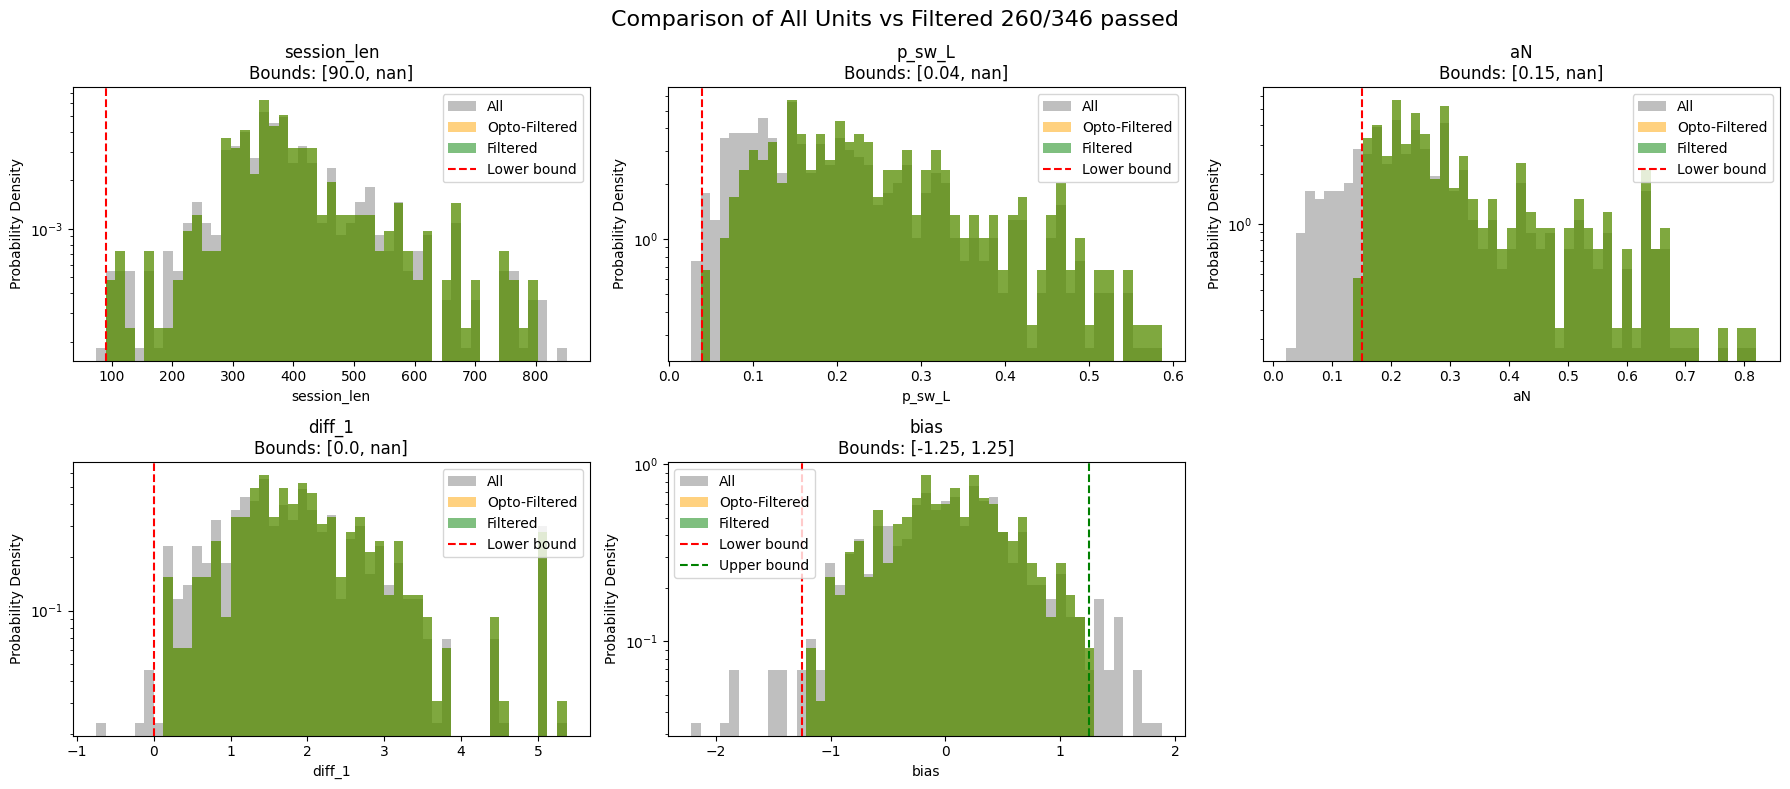

In [3]:
beh_criteria = 'beh_only'
with open(os.path.join('/root/capsule/code/beh_ephys_analysis/session_combine/metrics', f'{beh_criteria}.json'), 'r') as f:
    beh_constraints = json.load(f)
combined_session_tbl_filtered, combined_session_tbl, fig, axes = apply_qc(combined_session_tbl, beh_constraints)

In [4]:
# results, fig = fit_glm_session_list(combined_session_tbl_filtered['session'].to_list(), plot=True)

In [5]:
from joblib import Parallel, delayed
import numpy as np
import statsmodels.api as sm


def prepare_glm_session(sess, max_lag=5, model_name='stan_qLearning_5params'):
    """
    Prepare per-session design matrices and targets for GLM fitting.
    Returns None if session is invalid.
    """
    if get_session_tbl(sess) is None:
        return None

    sess_df = makeSessionDF(
        sess,
        cut_interruptions=True,
        model_name=model_name
    )

    if sess_df is None or len(sess_df) == 0:
        return None

    choice_raw = sess_df['choice'].values.copy()
    choice = 2 * (choice_raw - 0.5)   # {-1, +1}
    choice_prev = sess_df['choices_prev'].values
    choice_prev = 2 * (choice_prev - 0.5)   # {-1, +1}
    outcome = sess_df['outcome'].values

    reward_side = choice * outcome
    noreward_side = choice * (1 - outcome)

    n_trials = len(choice)

    reward_side_hist_mat = np.full((n_trials, max_lag), np.nan)
    noreward_side_hist_mat = np.full((n_trials, max_lag), np.nan)
    choice_hist_mat = np.full((n_trials, max_lag), np.nan)
    choice_hist_mat_for_switch = np.full((n_trials, max_lag), np.nan)

    for lag in range(1, max_lag + 1):
        reward_side_hist_mat[lag:, lag - 1] = reward_side[:-lag]
        noreward_side_hist_mat[lag:, lag - 1] = noreward_side[:-lag]
        choice_hist_mat[lag:, lag - 1] = choice[:-lag]
        choice_hist_mat_for_switch[(lag+1):, lag - 1] = choice[:-(lag+1)]

    return {
        'session': sess,
        'reward_side_hist_mat': reward_side_hist_mat,
        'noreward_side_hist_mat': noreward_side_hist_mat,
        'choice_hist_mat': choice_hist_mat,
        'choice_hist_mat_for_switch': choice_hist_mat_for_switch,
        'choices': choice_raw,
        'choices_prev': choice_prev,
        'session_len': n_trials,
    }


def fit_glm_session_list_par(
    session_list,
    max_lag=5,
    plot=False,
    n_jobs=-1,
    backend='loky',
    model_name='stan_qLearning_5params',
    fit_kwargs=None,
    return_dict=False,
):
    """
    Parallelized GLM fitting across sessions while concatenating trials across sessions.

    Returns
    -------
    By default:
        result_rwd_choice,
        result_rwd_norwd,
        result_switch_rwd_norwd,
        result_switch_norwd_choice,
        result_switch_rwd_choice,
        choice_prob_by_session,
        switch_prob_by_session

    If return_dict=True:
        returns a dict with the same contents.
    """
    if fit_kwargs is None:
        fit_kwargs = {'disp': False}

    prepared = Parallel(n_jobs=n_jobs, backend=backend)(
        delayed(prepare_glm_session)(sess, max_lag=max_lag, model_name=model_name)
        for sess in session_list
    )

    prepared = [x for x in prepared if x is not None]

    if len(prepared) == 0:
        raise ValueError("No valid sessions found in the provided session list.")

    session_list_valid = [x['session'] for x in prepared]
    session_lens = [x['session_len'] for x in prepared]

    all_reward_side_hist_mat = np.vstack([x['reward_side_hist_mat'] for x in prepared])
    all_noreward_side_hist_mat = np.vstack([x['noreward_side_hist_mat'] for x in prepared])
    all_choice_hist_mat = np.vstack([x['choice_hist_mat'] for x in prepared])
    all_choice_hist_mat_for_switch = np.vstack([x['choice_hist_mat_for_switch'] for x in prepared])
    all_choices = np.hstack([x['choices'] for x in prepared])
    all_choices_prev = np.hstack([x['choices_prev'] for x in prepared])

    # 1) choice ~ reward side + choice history
    X = np.hstack([all_reward_side_hist_mat, all_choice_hist_mat])
    X = sm.add_constant(X, has_constant='add')
    model = sm.Logit(all_choices, X, missing='drop')
    result_rwd_choice = model.fit(**fit_kwargs)

    # 2) choice ~ reward side + no-reward side
    X = np.hstack([all_reward_side_hist_mat, all_noreward_side_hist_mat])
    X = sm.add_constant(X, has_constant='add')
    model = sm.Logit(all_choices, X, missing='drop')
    result_rwd_norwd = model.fit(**fit_kwargs)

    # 3) switch ~ reward side*prev_choice + no-reward side*prev_choice
    all_reward_side_hist_mat_inter = all_reward_side_hist_mat * all_choices_prev[:, np.newaxis]
    all_noreward_side_hist_mat_inter = all_noreward_side_hist_mat * all_choices_prev[:, np.newaxis]
    all_choices_switch = (all_choices != all_choices_prev).astype(float)
    valid_idx = ~np.isnan(all_choices_prev)

    X = np.hstack([
        all_reward_side_hist_mat_inter[valid_idx],
        all_noreward_side_hist_mat_inter[valid_idx]
    ])
    X = sm.add_constant(X, has_constant='add')
    model = sm.Logit(all_choices_switch[valid_idx], X, missing='drop')
    result_switch_rwd_norwd = model.fit(**fit_kwargs)

    # 4) switch ~ no-reward side*prev_choice + choice history*prev_choice
    all_noreward_side_hist_mat_inter = all_noreward_side_hist_mat * all_choices_prev[:, np.newaxis]
    all_choice_hist_mat_inter = all_choice_hist_mat_for_switch * all_choices_prev[:, np.newaxis]

    X = np.hstack([
        all_noreward_side_hist_mat_inter[valid_idx],
        all_choice_hist_mat_inter[valid_idx]
    ])
    X = sm.add_constant(X, has_constant='add')
    model = sm.Logit(all_choices_switch[valid_idx], X, missing='drop')
    result_switch_norwd_choice = model.fit(**fit_kwargs)

    # 5) switch ~ reward side*prev_choice + choice history*prev_choice
    all_reward_side_hist_mat_inter = all_reward_side_hist_mat * all_choices_prev[:, np.newaxis]
    all_choice_hist_mat_inter = all_choice_hist_mat_for_switch * all_choices_prev[:, np.newaxis]

    X = np.hstack([
        all_reward_side_hist_mat_inter[valid_idx],
        all_choice_hist_mat_inter[valid_idx]
    ])
    X = sm.add_constant(X, has_constant='add')
    model = sm.Logit(all_choices_switch[valid_idx], X, missing='drop')
    result_switch_rwd_choice = model.fit(**fit_kwargs)

    # # 5) switch ~ no-reward side*prev_choice + reward side*prev_choice + choice history*prev_choice
    # all_reward_side_hist_mat_inter = all_reward_side_hist_mat * all_choices_prev[:, np.newaxis]
    # all_noreward_side_hist_mat_inter = all_noreward_side_hist_mat * all_choices_prev[:, np.newaxis]
    # all_choice_hist_mat_inter = all_choice_hist_mat_for_switch * all_choices_prev[:, np.newaxis]
    # valid_idx = ~np.isnan(all_choices_prev)
    # X = np.hstack([
    #     all_reward_side_hist_mat_inter[valid_idx],
    #     all_noreward_side_hist_mat_inter[valid_idx],
    #     all_choice_hist_mat_inter[valid_idx]
    # ])
    # X = sm.add_constant(X, has_constant='add')
    # model = sm.Logit(all_choices_switch[valid_idx], X, missing='drop')
    # result_switch_full = model.fit(**fit_kwargs)

    # choice probability from model 1
    X_pred = np.hstack([all_reward_side_hist_mat, all_choice_hist_mat])
    X_pred = sm.add_constant(X_pred, has_constant='add')
    choice_prob = result_rwd_choice.predict(X_pred)

    left_choices = all_choices == 0
    choice_prob[left_choices] = 1 - choice_prob[left_choices]

    # switch probability from model 4
    X_pred_switch = np.hstack([
        all_noreward_side_hist_mat_inter[valid_idx],
        all_choice_hist_mat_inter[valid_idx]
    ])
    X_pred_switch = sm.add_constant(X_pred_switch, has_constant='add')
    switch_prob_valid = result_switch_norwd_choice.predict(X_pred_switch)

    switch_prob = np.full(len(all_choices), np.nan)
    switch_prob[valid_idx] = switch_prob_valid


    # split back by session
    choice_prob_by_session = {}
    switch_prob_by_session = {}

    start_idx = 0
    for sess, sess_len in zip(session_list_valid, session_lens):
        end_idx = start_idx + sess_len
        choice_prob_by_session[sess] = choice_prob[start_idx:end_idx]
        switch_prob_by_session[sess] = switch_prob[start_idx:end_idx]
        start_idx = end_idx


    results = {
        "models": {
            "choice_reward_choice": result_rwd_choice,
            "choice_reward_noreward": result_rwd_norwd,
            "switch_reward_noreward": result_switch_rwd_norwd,
            "switch_noreward_choice": result_switch_norwd_choice,
            "switch_reward_choice": result_switch_rwd_choice,
            # "switch_full": result_switch_full,
        },

        "choice_prob_by_session": choice_prob_by_session,
        "switch_prob_by_session": switch_prob_by_session,

        "session_list_valid": session_list_valid,
        "session_lens": session_lens,
        "max_lag": max_lag
    }

    return results


def plot_glm_session_results(results, figsize=None, sharey=False):

    models = results["models"]
    max_lag = results["max_lag"]

    model_specs = [
        ("choice_reward_choice",
         "Choice: reward + choice",
         ["Reward side", "Choice history"]),

        ("choice_reward_noreward",
         "Choice: reward + no-reward",
         ["Reward side", "No-reward side"]),

        ("switch_reward_noreward",
         "Switch: reward + no-reward",
         ["Reward × prev", "No-reward × prev"]),

        ("switch_noreward_choice",
         "Switch: no-reward + choice",
         ["No-reward × prev", "Choice × prev"]),

        ("switch_reward_choice",
         "Switch: reward + choice",
         ["Reward × prev", "Choice × prev"]),

        #  ("switch_full",
        #  "Switch: reward + no-reward + choice",
        #  ["Reward × prev", "No-reward × prev", "Choice × prev"])
    ]
    if figsize is None:
        figsize = (5*len(model_specs), 5)
    fig, axes = plt.subplots(1,len(model_specs),figsize=figsize,sharey=sharey)
    axes = axes.flatten()

    lags = np.arange(1, max_lag+1)

    for ax,(key,title,labels) in zip(axes,model_specs):

        result = models[key]

        params = np.asarray(result.params)
        bse = np.asarray(result.bse)

        beta1 = params[1:1+max_lag]
        beta2 = params[1+max_lag:1+2*max_lag]

        err1 = bse[1:1+max_lag]
        err2 = bse[1+max_lag:1+2*max_lag]

        ax.errorbar(lags,beta1,yerr=err1,marker="o",label=labels[0])
        ax.errorbar(lags,beta2,yerr=err2,marker="o",label=labels[1])

        ax.axhline(0,ls="--",lw=1)
        ax.set_title(title)
        ax.set_xlabel("Lag")
        ax.set_xticks(lags)
        ax.legend(frameon=False)

    axes[0].set_ylabel("Coefficient")

    for ax in axes[len(model_specs):]:
        ax.axis("off")

    plt.tight_layout()

    return fig,axes

In [6]:
results = fit_glm_session_list_par(combined_session_tbl_filtered['session'].to_list(), n_jobs=12, max_lag=10)


No raw session directory found for behavior_ZS059_2021-04-18_17-26-19.
No raw session directory found for behavior_ZS059_2021-04-18_17-26-19.
No raw session directory found for behavior_ZS059_2021-04-18_17-26-19.
No raw session directory found for behavior_ZS059_2021-04-18_17-26-19.
No raw session directory found for behavior_ZS060_2021-04-10_16-58-41.
No raw session directory found for behavior_ZS060_2021-04-11_16-41-30.
No raw session directory found for behavior_ZS060_2021-04-14_18-15-27.
No raw session directory found for behavior_ZS060_2021-04-11_16-41-30.
No raw session directory found for behavior_ZS060_2021-04-11_16-41-30.
No raw session directory found for behavior_ZS060_2021-04-10_16-58-41.
No raw session directory found for behavior_ZS060_2021-04-10_16-58-41.
No raw session directory found for behavior_ZS060_2021-04-11_16-41-30.
No raw session directory found for behavior_ZS060_2021-04-10_16-58-41.
No raw session directory found for behavior_ZS060_2021-04-21_19-23-52.
No raw

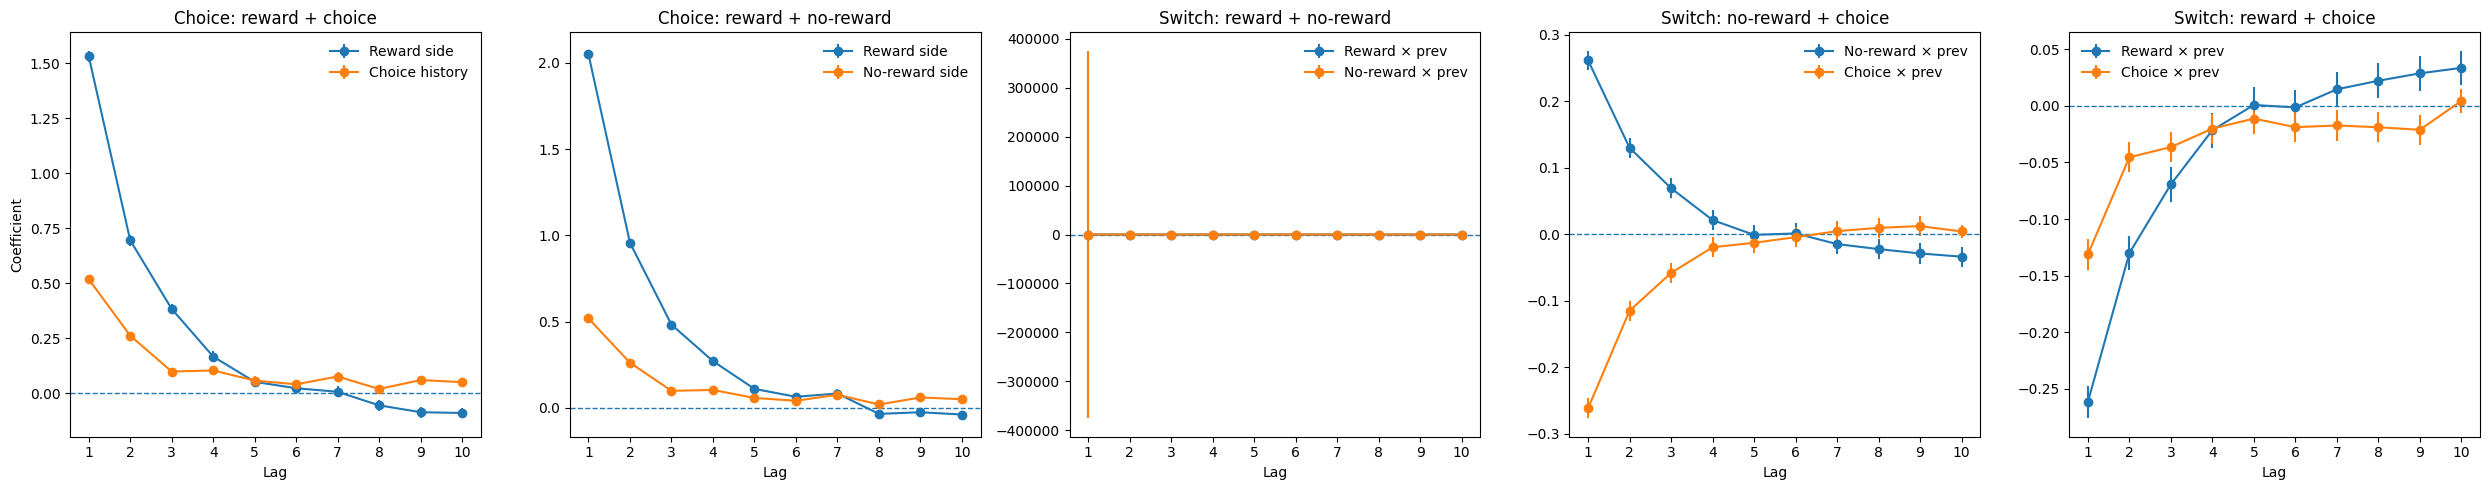

In [7]:
fig, _ = plot_glm_session_results(results);
fig.savefig(os.path.join(target_folder, 'glm_combined_sessions.pdf'))

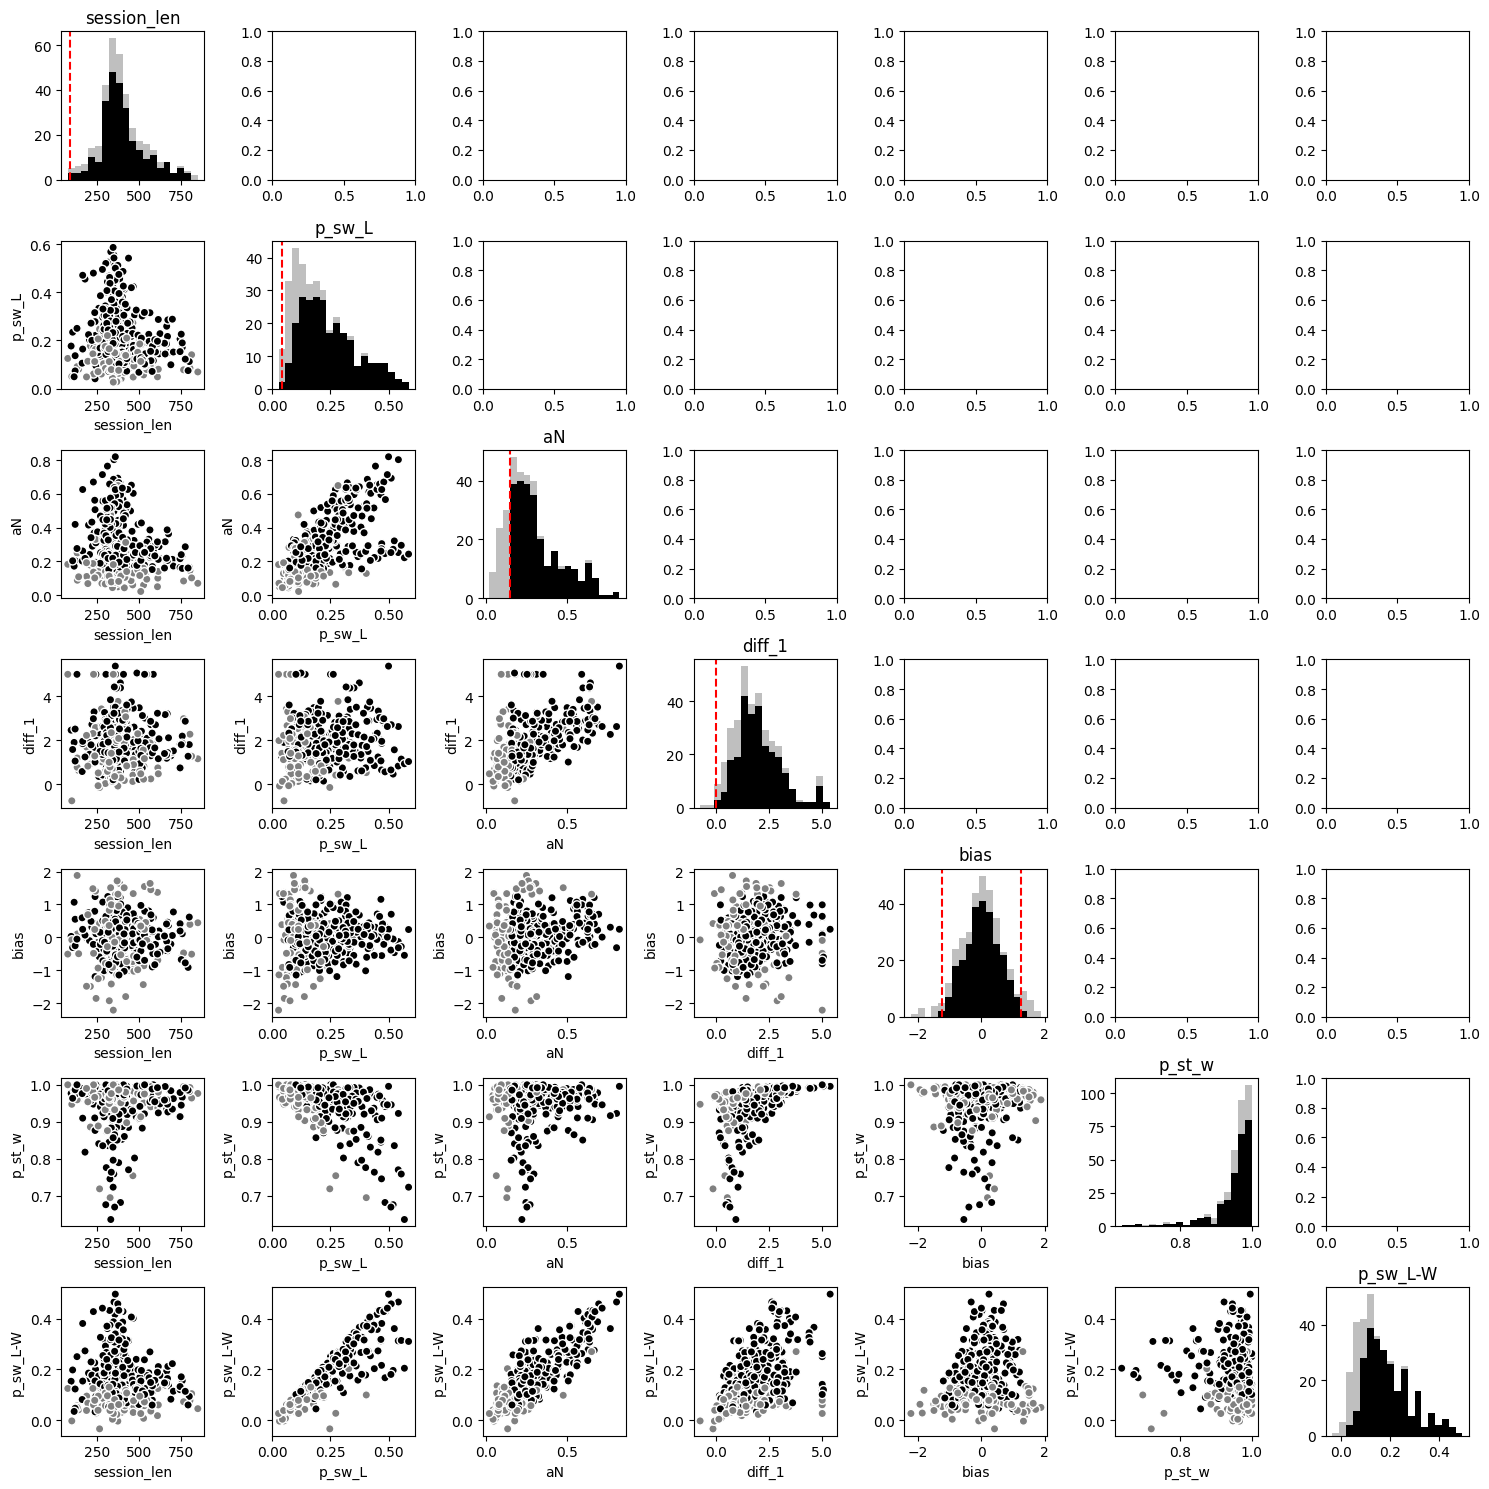

In [10]:
# scatter plot of qm_cols and color code pass vs fail
qm_cols = list(beh_constraints.keys())
qm_cols.append('p_st_w')
qm_cols.append('p_sw_L-W')
fig, axes = plt.subplots(len(qm_cols), len(qm_cols), figsize=(15,15))
for i, col_x in enumerate(qm_cols):
    for j, col_y in enumerate(qm_cols):
        ax = axes[j, i]
        if i == j:
            bins = np.linspace(combined_session_tbl[col_x].min(), combined_session_tbl[col_x].max(), 20)
            ax.hist(combined_session_tbl[col_x].dropna(), bins=bins, edgecolor=None, facecolor = 'gray', alpha=0.5)
            ax.hist(combined_session_tbl_filtered[col_x].dropna(), bins=bins, edgecolor=None, facecolor = 'k', alpha=1)
            ax.set_title(col_x)
            if col_x in beh_constraints.keys():
                for boundary in beh_constraints[col_x]['bounds']:
                    if boundary is not None:
                        ax.axvline(boundary, color='red', linestyle='--')

        elif i < j:
            ax.scatter(combined_session_tbl[col_x], combined_session_tbl[col_y], 
                        c=combined_session_tbl['session_id'].isin(combined_session_tbl_filtered['session_id']).map({True: 'k', False: 'gray'}), 
                        alpha=1, edgecolors='white')
    
            ax.set_xlabel(col_x)
            ax.set_ylabel(col_y)
plt.tight_layout()

plt.savefig(os.path.join(target_folder, 'behavior_qm_scatter.pdf'))


In [11]:
session_list = combined_session_tbl_filtered['session_id'].tolist()
model_name = 'stan_qLearning_5params'

In [67]:
# comcation of all sessionss
# pe, p_Right, Q_R, Q_L, policy_change, policy_update_mean etc
focus_cols = ['outcome', 'choice',
                'Q_r', 'Q_l', 'pe', 'p_Right', 'p_Right_glm', 'pChoice', 'pChoice_glm',
                'policy_change', 'policy_change_log_odd', 'policy_update_mean', 
                'policy_glm_change', 'policy_glm_change_log_odd', 'policy_glm_update_mean']
count_win = [0, 1]
def process(session):
    print(session)
    if get_session_tbl(session) is not None:
        session_tbl_raw = get_session_tbl(session) 
        sess_df = makeSessionDF(session, model_name=model_name, cut_interruptions=True, load_glm=True)
        if 'pChoice' in sess_df.columns:
             # compute p_Right
            p_right = sess_df['pChoice'].values.copy()
            p_right[sess_df['choice']==0] = 1 - p_right[sess_df['choice']==0]
            sess_df['p_Right'] = p_right
        if 'pChoice_glm' in sess_df.columns:
            p_right_glm = sess_df['pChoice_glm'].values.copy()
            p_right_glm[sess_df['choice']==0] = 1 - p_right_glm[sess_df['choice']==0]
            sess_df['p_Right_glm'] = p_right_glm
        # select focus columns that is included in the session dataframe and set the ones that are not included to NaN
        # count number of licks after outcome
        lick_data = load_licks(session)
        all_licks = np.concatenate((lick_data['licks_L_cleaned'], lick_data['licks_R_cleaned']))
        all_licks = np.sort(all_licks)
        align_times = sess_df['outcome_time'].values
        lick_counts = np.full(len(align_times), np.nan)
        for i, align_time in enumerate(align_times):
            lick_counts[i] = np.sum((all_licks >= align_time + count_win[0]) & (all_licks < align_time + count_win[1]))
        sess_df['lick_rate_post_outcome'] = lick_counts/(count_win[1]-count_win[0])

        # response rate
        start_per = int(np.round(np.percentile(np.where(session_tbl_raw['animal_response'].values!=2), 5)))
        stop_per = int(np.round(np.percentile(np.where(session_tbl_raw['animal_response'].values!=2), 95)))
        sess_df['hit_rate'] = np.mean(session_tbl_raw['animal_response'].values[start_per:stop_per]!=2)

        for col in focus_cols:
            if col not in sess_df.columns:
                sess_df[col] = np.nan
        return sess_df, session
    else:
        return None, session
        


In [68]:
process('behavior_751181_2025-02-26_11-51-19')

behavior_751181_2025-02-26_11-51-19


(     outcome  choice  laser  outcome_prev  laser_prev  choices_prev  \
 29       1.0     1.0    0.0           0.0         0.0           0.0   
 30       0.0     1.0    0.0           1.0         0.0           1.0   
 31       0.0     1.0    0.0           0.0         0.0           1.0   
 32       0.0     1.0    0.0           0.0         0.0           1.0   
 33       0.0     1.0    0.0           0.0         0.0           1.0   
 ..       ...     ...    ...           ...         ...           ...   
 118      0.0     1.0    0.0           0.0         0.0           0.0   
 119      1.0     0.0    0.0           0.0         0.0           1.0   
 120      0.0     0.0    0.0           1.0         0.0           0.0   
 121      0.0     1.0    0.0           0.0         0.0           0.0   
 122      0.0     0.0    0.0           0.0         0.0           1.0   
 
       go_cue_time   choice_time  outcome_time    svs  ...   Qchosen  \
 29   5.875845e+06  5.875845e+06  5.875845e+06   True  ...  0.

In [69]:
from joblib import Parallel, delayed
results = Parallel(n_jobs=-1)(delayed(process)(session) for session in session_list)
# all_sess_df = pd.concat(all_sess_dfs, ignore_index=True)

behavior_716325_2024-05-29_10-33-32
behavior_751004_2024-12-22_13-09-17
behavior_751769_2025-01-16_11-32-05
behavior_751769_2025-01-17_11-37-39
behavior_751769_2025-01-18_10-15-25
behavior_758017_2025-02-04_11-57-38
behavior_758017_2025-02-05_11-42-34
behavior_758017_2025-02-06_11-26-14
behavior_751766_2025-02-13_11-31-21
behavior_751766_2025-02-11_11-53-38
behavior_751766_2025-02-15_12-08-11
behavior_751766_2025-02-14_11-37-11
behavior_751181_2025-02-25_12-12-35
behavior_751181_2025-02-26_11-51-19
behavior_754897_2025-03-12_12-23-15
behavior_758018_2025-03-20_11-53-05


/opt/conda/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.10/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


behavior_758018_2025-03-21_11-00-34


/opt/conda/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.10/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


behavior_752014_2025-03-26_11-18-57


...

/opt/conda/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.10/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.10/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.10/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3

behavior_754896_2025-01-04_17-25-58
behavior_754896_2025-01-06_16-37-09
behavior_754896_2025-01-07_14-08-54
behavior_754896_2025-01-08_16-03-27


/opt/conda/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.10/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.10/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


behavior_754896_2025-01-09_16-22-47


/opt/conda/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.10/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.10/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.10/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3

In [70]:
all_sess_df, processed_sessions = [], []
for res in results:
    if res[0] is not None:
        all_sess_df.append(res[0])
        processed_sessions.append(res[1])

In [71]:
for sess_id, sess_df in enumerate(all_sess_df):
    if sess_df is None or sess_df.empty:
        print(f'Session {processed_sessions[sess_id]} is empty')
        continue
    if 'outcome' not in sess_df.columns:
        print(f'Outcome not in {processed_sessions[sess_id]}')

In [72]:
session_len = [len(sess_df) for sess_df in all_sess_df]
session_len_time = [(sess_df['goCue_start_time'].iloc[-1] - sess_df['goCue_start_time'].iloc[0])/60 if sess_df is not None else np.nan for sess_df in all_sess_df]
p_correct = [np.mean(sess_df['pChoice']>=0.5) if sess_df is not None and 'pChoice' in sess_df.columns else np.nan for sess_df in all_sess_df]
# set p_correct is 0 to np.nan
p_correct = [p if p>0 else np.nan for p in p_correct]

p_correct_glm = [np.mean(sess_df['pChoice_glm']>=0.5) if sess_df is not None and 'pChoice_glm' in sess_df.columns else np.nan for sess_df in all_sess_df]
# set p_correct_glm is 0 to np.nan
reward_rate = [np.mean(sess_df['outcome']) if sess_df is not None else np.nan for sess_df in all_sess_df ]
hit_rate = [sess_df['hit_rate'].values[0] if sess_df is not None else np.nan for sess_df in all_sess_df ]

summary_df = pd.DataFrame({'session_id': processed_sessions,
                            'session_len': session_len,
                            'session_len_time': session_len_time,
                            'p_correct': p_correct,
                            'p_correct_glm': p_correct_glm,
                            'reward_rate': reward_rate,
                            'hit_rate': hit_rate})



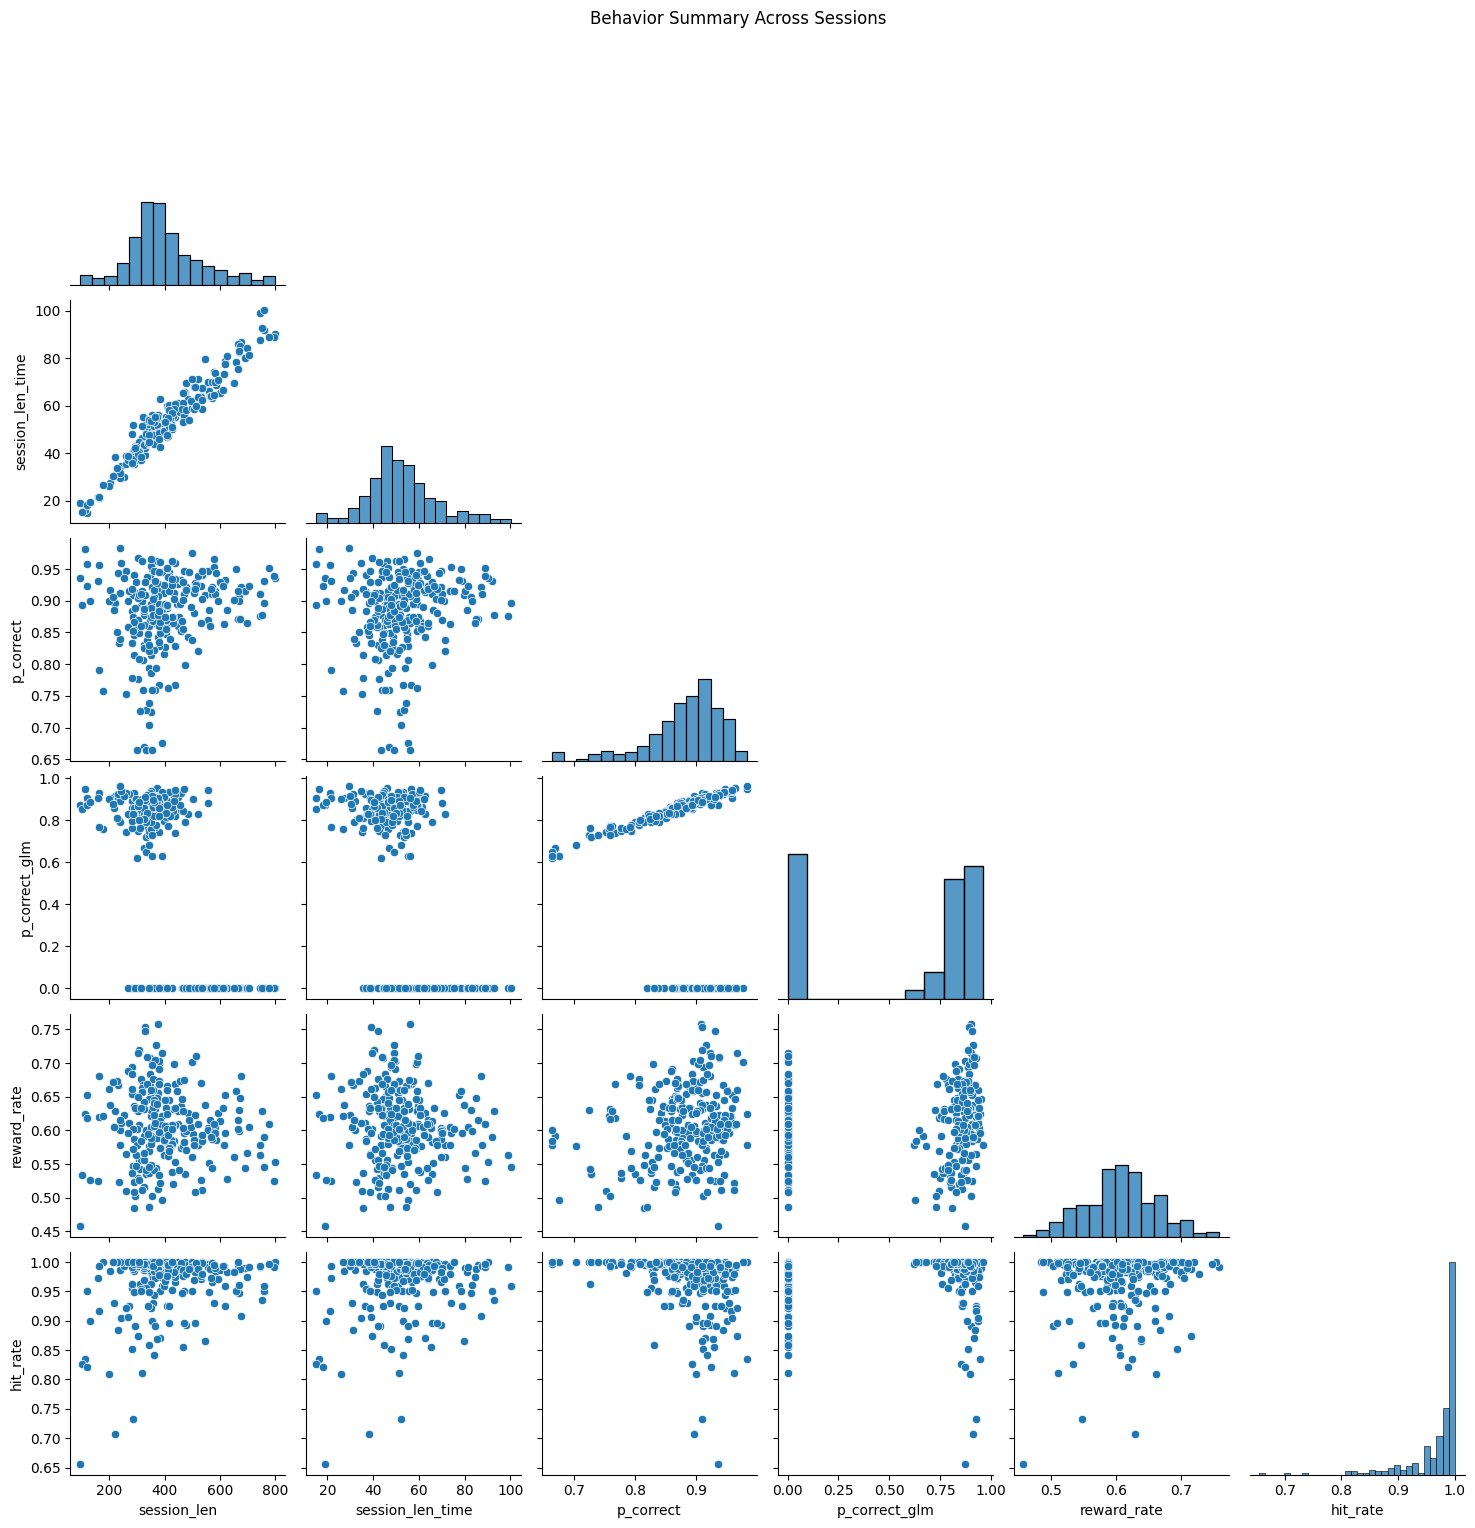

In [73]:
g = sns.pairplot(summary_df[['session_len', 'session_len_time', 'p_correct', 'p_correct_glm', 'reward_rate', 'hit_rate']], corner=True)
g.fig.suptitle('Behavior Summary Across Sessions', y=1.02)
plt.savefig(os.path.join(target_folder, 'model_prediction_summary_scatter.pdf'))

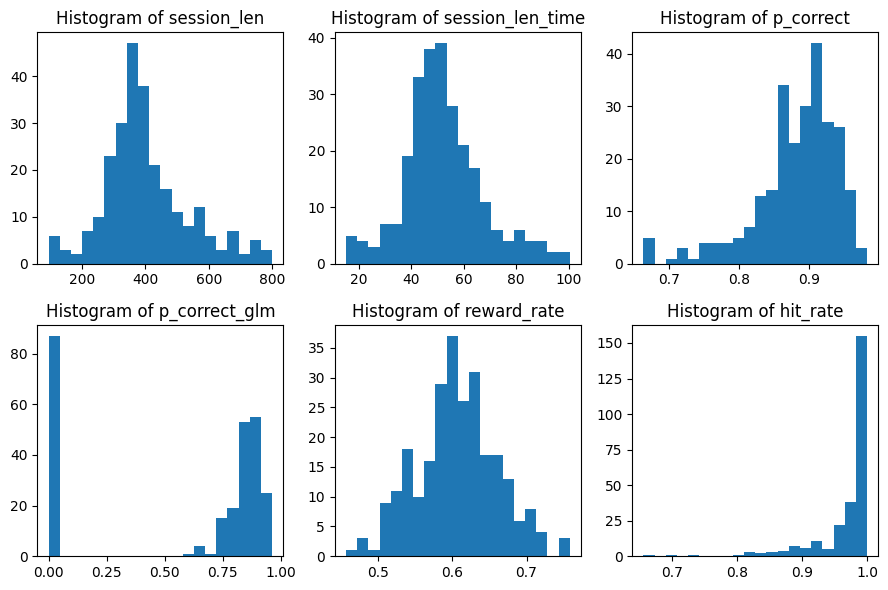

In [75]:
# histogram of all summary stats
focus_cols = ['session_len', 'session_len_time', 'p_correct', 'p_correct_glm', 'reward_rate', 'hit_rate']
fig, axes = plt.subplots(2, 3, figsize=(9,6))
for i, col in enumerate(focus_cols):
    ax = axes[i//3, i%3]
    ax.hist(summary_df[col].dropna(), bins=20, edgecolor=None)
    ax.set_title(f'Histogram of {col}')
plt.tight_layout()
plt.savefig(os.path.join(target_folder, 'behavior_summary_stats_histogram.pdf'))

In [98]:
np.percentile(summary_df['hit_rate'], 10)

np.float64(0.9045251396648045)

In [ ]:
np.quantile(a, q)

## RL parameters

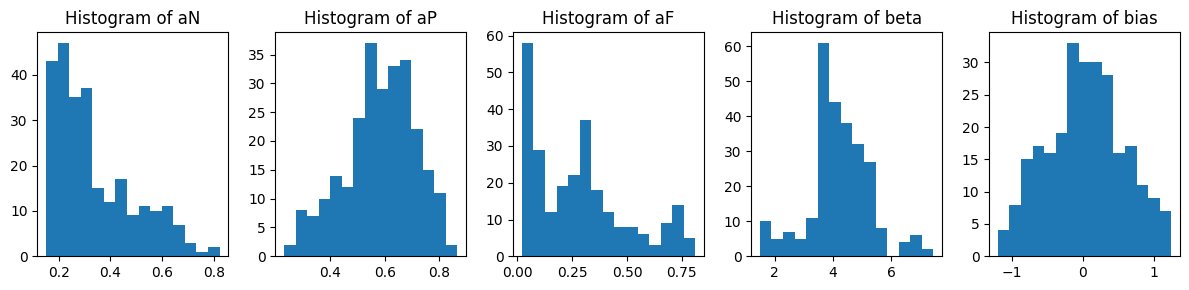

In [77]:
focus_params = ['aN', 'aP', 'aF', 'beta', 'bias']
fig, axes = plt.subplots(1, len(focus_params), figsize=(12,3))
for i, param in enumerate(focus_params):
    ax = axes[i]
    param_values = combined_session_tbl_filtered[param].dropna().values
    ax.hist(param_values, bins=15, edgecolor=None)
    ax.set_title(f'Histogram of {param}')
plt.tight_layout()
plt.savefig(os.path.join(target_folder, 'behavior_model_params_histogram.pdf'))

## Policy against RPE

In [78]:
policy_columns = ['policy_change', 'policy_change_log_odd', 'policy_update_mean', 'policy_glm_change', 'policy_glm_change_log_odd', 'policy_glm_update_mean']

In [79]:
all_session_combined = pd.concat(objs=all_sess_df, ignore_index=True)
num_bins = 9
bin_qualties = False

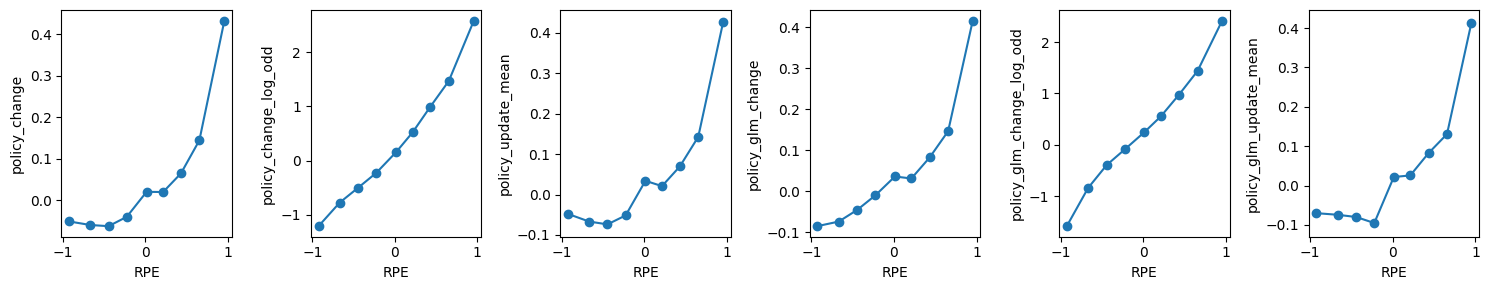

In [80]:
fig, axes = plt.subplots(1, len(policy_columns), figsize=(15, 3))
for i, col in enumerate(policy_columns):
    ax = axes[i]
    data = all_session_combined[col].values
    rpe = all_session_combined['pe'].values
    valid_idx = ~np.isnan(data) & ~np.isnan(rpe)
    data = data[valid_idx]
    rpe = rpe[valid_idx]
    if not bin_qualties:
        bins = np.linspace(np.nanmin(rpe), np.nanmax(rpe), num_bins+1) 
    else:
        bins = np.quantile(rpe, np.linspace(0, 1, num_bins+1))
    bin_means = np.full(num_bins, np.nan)
    policy_means = np.full(num_bins, np.nan)
    policy_sems = np.full(num_bins, np.nan)
    for ind in range(num_bins):
        bin_idx = (rpe >= bins[ind]) & (rpe < bins[ind+1])
        if np.sum(bin_idx) > 0:
            bin_means[ind] = np.nanmean(rpe[bin_idx])
            policy_means[ind] = np.nanmean(data[bin_idx])
            policy_sems[ind] = np.std(data[bin_idx])/np.sqrt(np.sum(bin_idx))
    ax.errorbar(bin_means, policy_means, yerr=policy_sems, fmt='-o')
    ax.set_xlabel('RPE')
    ax.set_ylabel(col)
plt.tight_layout()
plt.savefig(os.path.join(target_folder, 'policies_vs_rpe_all_combined.pdf'))


## policy vs rpe, calculate by session then combine

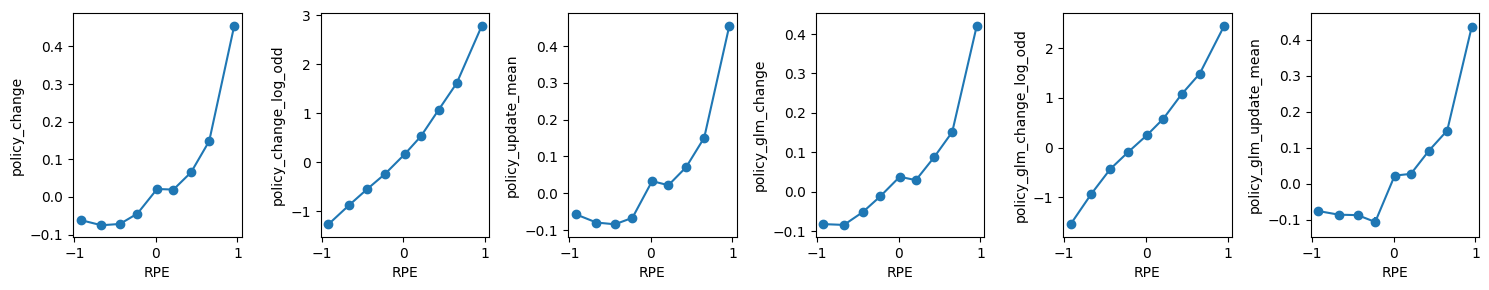

In [81]:
fig, axes = plt.subplots(1, len(policy_columns), figsize=(15, 3))

for i, col in enumerate(policy_columns):
    ax = axes[i]
    policy_mat = []
    rpe_mat = []
    for sess_df in all_sess_df:
        data = sess_df[col].values
        rpe = sess_df['pe'].values
        valid_idx = ~np.isnan(data) & ~np.isnan(rpe)
        data = data[valid_idx]
        rpe = rpe[valid_idx]
        if len(data) == 0:
            continue
        if not bin_qualties:
            bins = np.linspace(np.nanmin(rpe), np.nanmax(rpe), num_bins+1) 
        else:
            bins = np.quantile(rpe, np.linspace(0, 1, num_bins+1))
        bin_means = np.full(num_bins, np.nan)
        policy_means = np.full(num_bins, np.nan)
        for ind in range(num_bins):
            bin_idx = (rpe >= bins[ind]) & (rpe < bins[ind+1])
            if np.sum(bin_idx) > 0:
                bin_means[ind] = np.nanmean(rpe[bin_idx])
                policy_means[ind] = np.nanmean(data[bin_idx])
        rpe_mat.append(bin_means)
        policy_mat.append(policy_means)
    rpe_mat = np.array(rpe_mat)
    policy_mat = np.array(policy_mat)
    mean_rpe = np.nanmean(rpe_mat, axis=0)
    mean_policy = np.nanmean(policy_mat, axis=0)
    sem_policy = np.nanstd(policy_mat, axis=0)/np.sqrt(np.sum(~np.isnan(policy_mat), axis=0))
    ax.errorbar(mean_rpe, mean_policy, yerr=sem_policy, fmt='-o')
    ax.set_xlabel('RPE')
    ax.set_ylabel(col)
plt.tight_layout()
plt.savefig(os.path.join(target_folder, 'policies_vs_rpe_session_avg.pdf'))


## Lick rate vs rpe

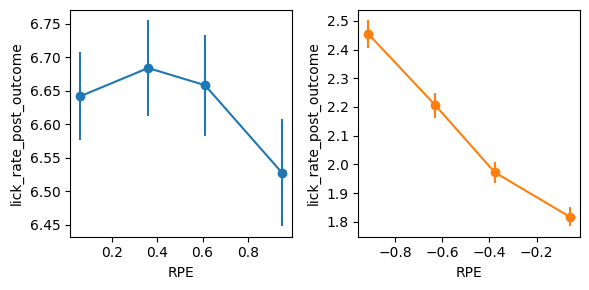

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
col = 'lick_rate_post_outcome'
lick_mat = []
rpe_mat = []
bin_quantiles = False
num_bins = 8
for sess_df in all_sess_df:
    data = sess_df[col].values
    rpe = sess_df['pe'].values
    valid_idx = ~np.isnan(data) & ~np.isnan(rpe)
    data = data[valid_idx]
    rpe = rpe[valid_idx]
    if len(data) == 0:
        continue
    if not bin_quantiles:
        bins = np.concat((np.linspace(-1, 0, num_bins//2 +1), np.linspace(0, 1, num_bins//2 +1)[1:]))
    else:
        bins = np.quantile(rpe, np.linspace(0, 1, num_bins+1))
    bin_means = np.full(num_bins, np.nan)
    lick_means = np.full(num_bins, np.nan)
    for ind in range(num_bins):
        bin_idx = (rpe >= bins[ind]) & (rpe < bins[ind+1])
        if np.sum(bin_idx) > 0:
            bin_means[ind] = np.nanmean(rpe[bin_idx])
            lick_means[ind] = np.nanmean(data[bin_idx])
    rpe_mat.append(bin_means)
    lick_mat.append(lick_means)
rpe_mat = np.array(rpe_mat)
lick_mat = np.array(lick_mat)
mean_rpe = np.nanmean(rpe_mat, axis=0)

mean_policy = np.nanmean(lick_mat, axis=0)
sem_policy = np.nanstd(lick_mat, axis=0)/np.sqrt(np.sum(~np.isnan(lick_mat), axis=0))
# plot lick with postive and negative rpe separately
ax = axes[0]
pos_idx = mean_rpe >= 0
ax.errorbar(mean_rpe[pos_idx], mean_policy[pos_idx], yerr=sem_policy[pos_idx], fmt='-o', color='tab:blue')
ax.set_xlabel('RPE')
ax.set_ylabel(col)
ax = axes[1]
neg_idx = mean_rpe < 0
ax.errorbar(mean_rpe[neg_idx], mean_policy[neg_idx], yerr=sem_policy[neg_idx], fmt='-o', color='tab:orange')
ax.set_xlabel('RPE')
ax.set_ylabel(col)
plt.tight_layout()
plt.savefig(os.path.join(target_folder, 'licks_vs_rpe_session_avg.pdf'))


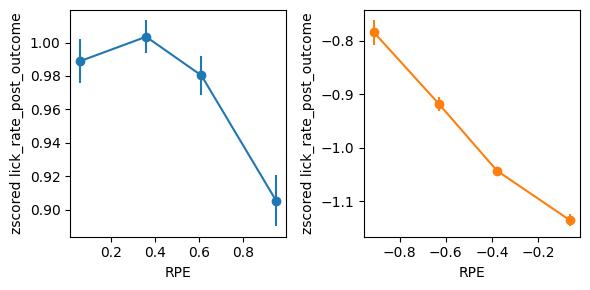

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
col = 'lick_rate_post_outcome'
lick_mat = []
rpe_mat = []
bin_quantiles = False
num_bins = 8
for sess_df in all_sess_df:
    data = sess_df[col].values
    rpe = sess_df['pe'].values
    valid_idx = ~np.isnan(data) & ~np.isnan(rpe)
    data = data[valid_idx]
    rpe = rpe[valid_idx]
    if len(data) == 0:
        continue
    if not bin_quantiles:
        bins = np.concat((np.linspace(-1, 0, num_bins//2 +1), np.linspace(0, 1, num_bins//2 +1)[1:]))
    else:
        bins = np.quantile(rpe, np.linspace(0, 1, num_bins+1))
    bin_means = np.full(num_bins, np.nan)
    lick_means = np.full(num_bins, np.nan)
    for ind in range(num_bins):
        bin_idx = (rpe >= bins[ind]) & (rpe < bins[ind+1])
        if np.sum(bin_idx) > 0:
            bin_means[ind] = np.nanmean(rpe[bin_idx])
            lick_means[ind] = np.nanmean(data[bin_idx])
    lick_means[~np.isnan(lick_means)] = zscore(lick_means[~np.isnan(lick_means)])
    rpe_mat.append(bin_means)
    lick_mat.append(lick_means)
rpe_mat = np.array(rpe_mat)
lick_mat = np.array(lick_mat)
mean_rpe = np.nanmean(rpe_mat, axis=0)

mean_policy = np.nanmean(lick_mat, axis=0)
sem_policy = np.nanstd(lick_mat, axis=0)/np.sqrt(np.sum(~np.isnan(lick_mat), axis=0))
# plot lick with postive and negative rpe separately
ax = axes[0]
pos_idx = mean_rpe >= 0
ax.errorbar(mean_rpe[pos_idx], mean_policy[pos_idx], yerr=sem_policy[pos_idx], fmt='-o', color='tab:blue')
ax.set_xlabel('RPE')
ax.set_ylabel(f'zscored {col}')
ax = axes[1]
neg_idx = mean_rpe < 0
ax.errorbar(mean_rpe[neg_idx], mean_policy[neg_idx], yerr=sem_policy[neg_idx], fmt='-o', color='tab:orange')
ax.set_xlabel('RPE')
ax.set_ylabel(f'zscored {col}')
plt.tight_layout()
plt.savefig(os.path.join(target_folder, 'zscored_licks_vs_rpe_session_avg.pdf'))


In [84]:
def plot_scatter_by_category(plot_col, cate_col):
    plot_mean_1 = []
    plot_mean_0 = []
    animal_ids = []
    for sess_df, session_id in zip(all_sess_df, processed_sessions):
        animal_id, _, _ = parseSessionID(session_id)
        data = sess_df[plot_col].values
        cat_val = sess_df[cate_col].values
        valid_idx = ~np.isnan(data) & ~np.isnan(cat_val)
        data = data[valid_idx]
        cat_val = cat_val[valid_idx]
        if len(data) == 0:
            continue
        plot_mean_1.append(np.nanmean(data[cat_val==1]))
        plot_mean_0.append(np.nanmean(data[cat_val==0]))
        animal_ids.append(animal_id)
    fig, ax = plt.subplots(figsize=(6,6))
    plot_df = pd.DataFrame({f'{plot_col}{cate_col}=1': plot_mean_1,
                                f'{plot_col}{cate_col}=0': plot_mean_0,
                                'animal_id': animal_ids})
    g = sns.scatterplot(data=plot_df, x=f'{plot_col}{cate_col}=0', y=f'{plot_col}{cate_col}=1', hue='animal_id', s=30, ax=ax)
    max_val = max(plot_df[f'{plot_col}{cate_col}=1'].max(), plot_df[f'{plot_col}{cate_col}=0'].max())
    ax.plot([0, max_val], [0, max_val], 'k--')
    ax.set_xlabel(f'Mean {plot_col} {cate_col}=0')
    ax.set_ylabel(f'Mean {plot_col} {cate_col}=1')
    plt.tight_layout()
    plt.savefig(os.path.join(target_folder, f'{plot_col}_{cate_col}_scatter_animal_color.pdf'))
    print(f'Saved figure to {target_folder} as {plot_col}_{cate_col}_scatter_animal_color.pdf')

Saved figure to /root/capsule/scratch/manuscript/F_beh as lick_rate_post_outcome_outcome_scatter_animal_color.pdf


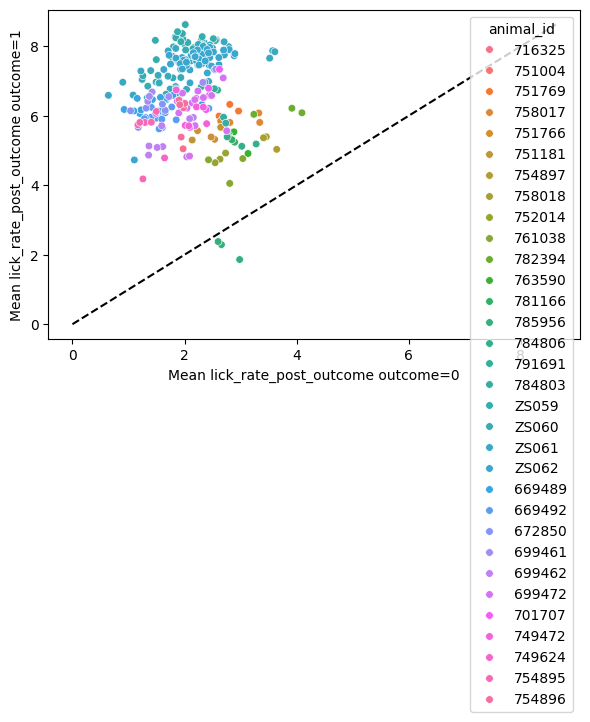

In [85]:
plot_scatter_by_category('lick_rate_post_outcome', 'outcome')

## Lick rate compare switch and stay

Saved figure to /root/capsule/scratch/manuscript/F_beh as lick_rate_post_outcome_svs_scatter_animal_color.pdf


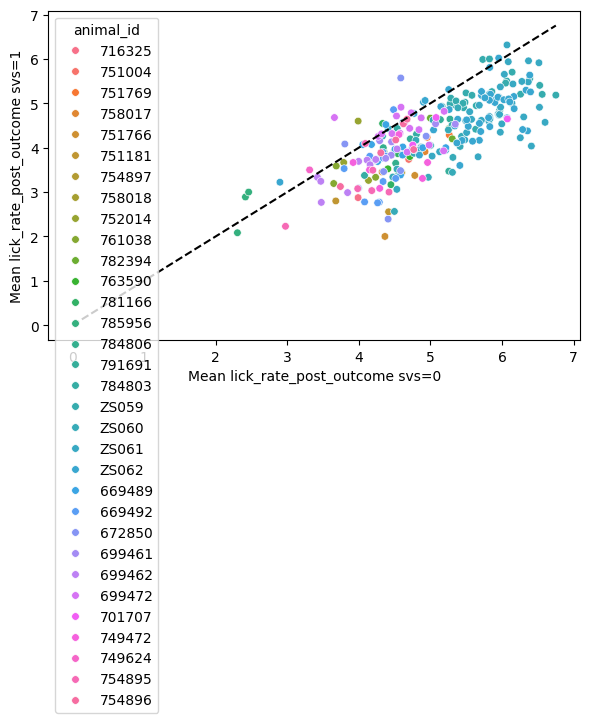

In [86]:
plot_scatter_by_category('lick_rate_post_outcome', 'svs')

Saved figure to /root/capsule/scratch/manuscript/F_beh as lick_lat_svs_scatter_animal_color.pdf


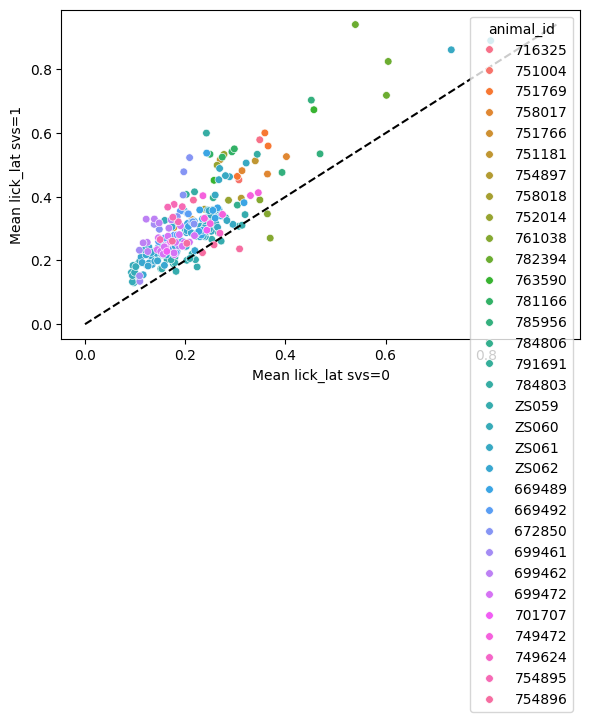

In [87]:
plot_scatter_by_category('lick_lat', 'svs')

In [88]:
# regression model of choices of all sessions